# Introduction

This project analyzes data from online dating application OKCupid. In recent
years, there has been a massive rise in the usage of dating apps to find love. Many of these apps use sophisticated data science techniques to recommend possible matches to users and to optimize the user experience. These apps give us access to a wealth of information that we've never had before about how different people experience romance.

The goal of this project is to scope, prep, analyze, and create a machine learning model to solve a question.

**Data Sources:**

`okcupid_profiles.csv` was provided by Kaggle.com.

## Scoping

### Project goals

In this project, the goal is to apply Machine Learning techniques to solve a problem. The main research topic of this project is to find whether a user's astrological sign can be predicted based on other information present on their profile. This project is important since many users find astrological signs an important part of matches, and if users don't input their sign, OkCupid would like to predict which sign they might be.

### Data

The project uses one dataset provided by Kaggle.com called `okcupid_profiles.csv`.In the data, each row represents an OKCupid user and the columns are the responses to their user profiles which include multi-choice and short answer questions.

### Analysis

This solution will use descriptive statistics and data visualization to find key figures in understanding the distribution, count, and relationship between variables. Since the goal of the project to make predictions on the user's astrological signs, classification algorithms from the supervised learning family of machine learning models will be implemented.

### Evaluation

The project will conclude with the evaluation of the machine learning model selected with a validation data set. The output of the predictions can be checked through a confusion matrix, and metrics such as accuracy, precision, recall, F1 and Kappa scores.

## Import Python modules

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from utils.data_ingestion import DataIngestorFactory

## Load Dataset

In [84]:
file_path = "data/raw_data.zip"
file_extension = os.path.splitext(file_path)[1]

ingestor = DataIngestorFactory.get_data_ingestor(file_extension)

profiles = ingestor.ingest(file_path)
profiles.head()

print(profiles.shape)

(59946, 31)


In [85]:
print(profiles.dtypes)

age              int64
status             str
sex                str
orientation        str
body_type          str
diet               str
drinks             str
drugs              str
education          str
ethnicity          str
height         float64
income           int64
job                str
last_online        str
location           str
offspring          str
pets               str
religion           str
sign               str
smokes             str
speaks             str
essay0             str
essay1             str
essay2             str
essay3             str
essay4             str
essay5             str
essay6             str
essay7             str
essay8             str
essay9             str
dtype: object


#### Data Characteristics

`okcupid_profiles.csv` has 59946 rows and 31 columns, this is a good sign since it  means we have enough data for Machine Learning

The columns in the dataset include:

- **age:** discrete variable of age of user
- **body_type:** categorical variable of body type of user
- **diet:** categorical variable of dietary information
- **drinks:**  categorical variable of alcohol consumption
- **drugs:** categorical variable of drug usage
- **education:** categorical variable of educational attainment
- **ethnicity:** categorical variable of ethnic backgrounds
- **height:** continuous variable of height of user
- **income:** discrete variable of income of user
- **job:** categorical variable of employment description
- **offspring:** categorical variable of children status
- **orientation:** categorical variable of sexual orientation
- **pets:** categorical variable of pet preferences
- **religion:** categorical variable of religious background
- **sex:** categorical variable of gender
- **sign:** categorical variable of astrological symbol
- **smokes:** categorical variable of smoking consumption
- **speaks:** categorical variable of language spoken
- **status:** categorical variable of relationship status
- **last_online:** date variable of last login
- **location:** categorical variable of user locations

And a set of open short-answer responses to :

- **essay0:** My self summary
- **essay1:**  What I’m doing with my life
- **essay2:** I’m really good at
- **essay3:** The first thing people usually notice about me
- **essay4:** Favorite books, movies, show, music, and food
- **essay5:** The six things I could never do without
- **essay6:** I spend a lot of time thinking about
- **essay7:** On a typical Friday night I am
- **essay8:** The most private thing I am willing to admit
- **essay9:** You should message me if…

## Explore The Data

Since this is a classification problem we need to check the number of unique categories for our target variable and what are those categories. Upon initial inspection there are 48 unique values for our target variable, this is because the is additional information appended to each record. We need to clean that up

In [86]:
print(f"Number of unique categories: {profiles.sign.nunique()}")
print(f"Unique categories: {profiles.sign.unique()}")

Number of unique categories: 48
Unique categories: <StringArray>
[                                       'gemini',
                                        'cancer',
            'pisces but it doesn&rsquo;t matter',
                                        'pisces',
                                      'aquarius',
                                        'taurus',
                                         'virgo',
                                   'sagittarius',
            'gemini but it doesn&rsquo;t matter',
            'cancer but it doesn&rsquo;t matter',
               'leo but it doesn&rsquo;t matter',
                                             nan,
          'aquarius but it doesn&rsquo;t matter',
       'aries and it&rsquo;s fun to think about',
             'libra but it doesn&rsquo;t matter',
      'pisces and it&rsquo;s fun to think about',
                                         'libra',
            'taurus but it doesn&rsquo;t matter',
       'sagittarius but it doesn&rs

#### Clean labels

It is important that we clean the labels since this is what will be predicted and 48 predictions would be quite difficult. By taking the first word of the column, the signs can be saved without the qualifiers. The qualifiers could be used for another problem down the line.

In [87]:
from utils.data_cleaning import remove_qualifiers_from_column

profiles["sign_clean"] = remove_qualifiers_from_column(profiles, "sign")
print(f"Number of unique categories: {profiles["sign_clean"].nunique()}")
print(f"Unique categories: {profiles["sign_clean"].unique()}")

Number of unique categories: 12
Unique categories: ['gemini' 'cancer' 'pisces' 'aquarius' 'taurus' 'virgo' 'sagittarius'
 'leo' nan 'aries' 'libra' 'scorpio' 'capricorn']


## Continuous Variables

Bellow the distribution of the variable `age` is shown. It seems that most of the users are in their late 20s to early 30s

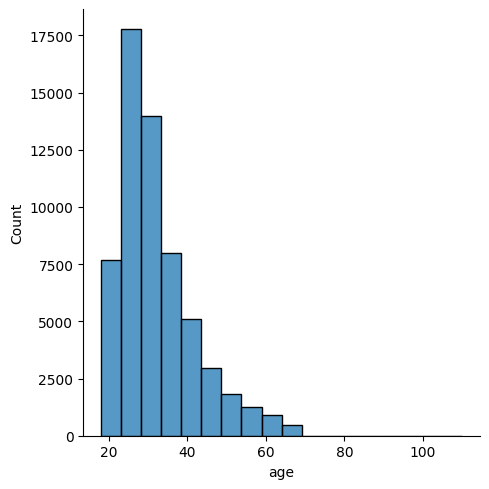

In [88]:
from utils.visualizations import display_distribution_plot, display_count_plot, column_value_counts

display_distribution_plot(profiles, "age")

Here is the same chart broken down by gender. It seems that there are slightly fewer women than men.

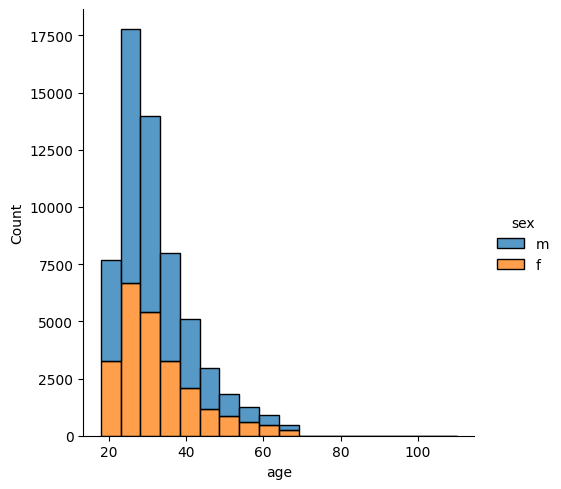

In [89]:
display_distribution_plot(profiles, "age", hue="sex")

### Height

Bellow the distribution of the variable `height` is shown. Most people look like they are between 5 feet tall and 6.5 feet tall.

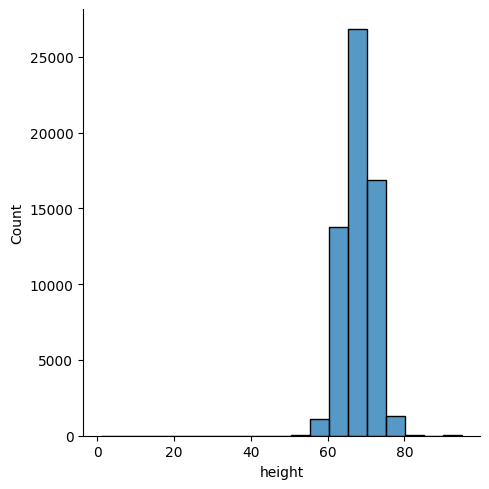

In [90]:
display_distribution_plot(profiles, "height")

Here is the same height chart broken down by gender. It seems obvious, but women tend to be shorter than men.

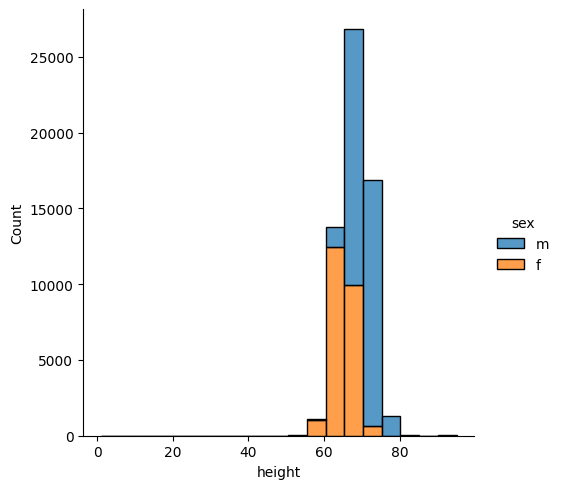

In [91]:
display_distribution_plot(profiles, "height", hue="sex")

### Income

Here is the distribution of income broken by gender. It seems that most users don't include their income.

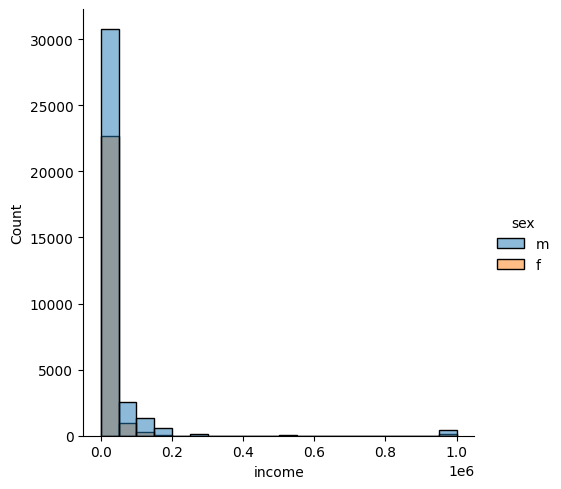

In [92]:
sns.displot(data=profiles, x="income", bins=20, hue="sex")
plt.show()

## Discreate Variables

### Sex

Here is a chart of the gender distribution. As seen before there are more male than female users.

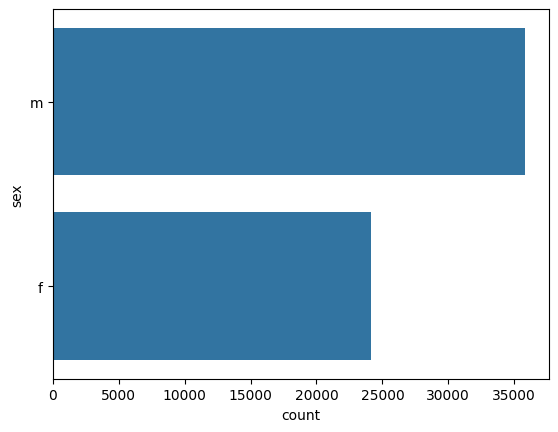

In [93]:
display_count_plot(profiles, "sex")

### Body Type


The next chart shows the body type variable. It seems that more users identify themselves as athletic, fit or average.


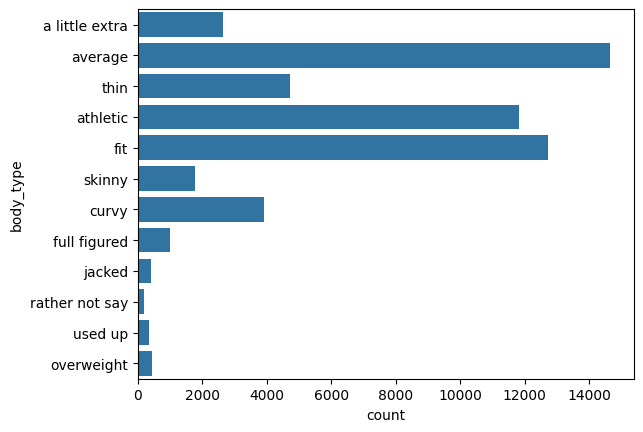

In [94]:
display_count_plot(profiles, "body_type")

Here the body_type is broken down by gender. Highly used description by female users seem to be "average", "fit" and curvy; and for the male users "average", "athletic" and "fit"

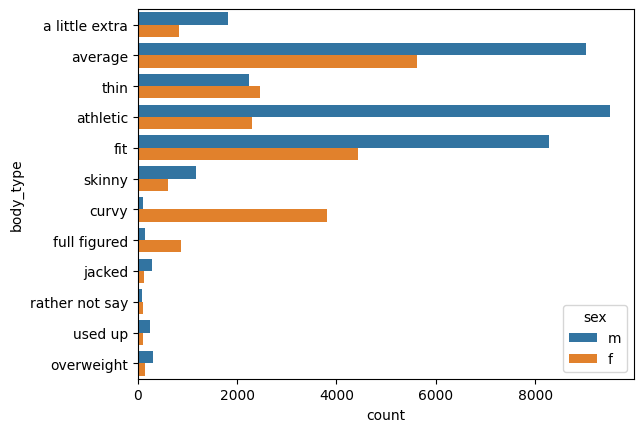

In [95]:
display_count_plot(profiles, "body_type", hue="sex")

### Diet

Here is a chart of the dietary information for users. Most user eat "mostly anything", followed by "anything", and "strictly anything", being open-minded seems to be a popular signal to potential partners.

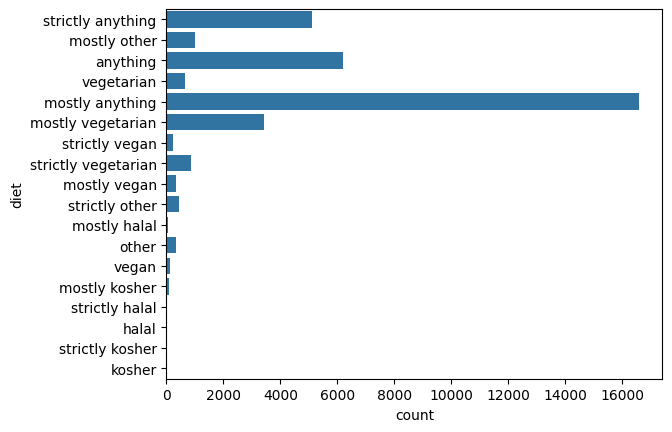

In [96]:
display_count_plot(profiles, "diet")

### Drinks

It seems that most of the users drink "socially", then "rarely" and "often"

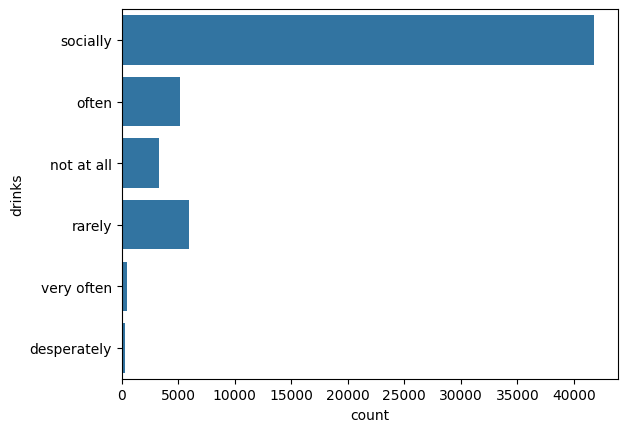

In [97]:
display_count_plot(profiles, "drinks")

### Drugs

It seems that a vast majority of users don't use drugs

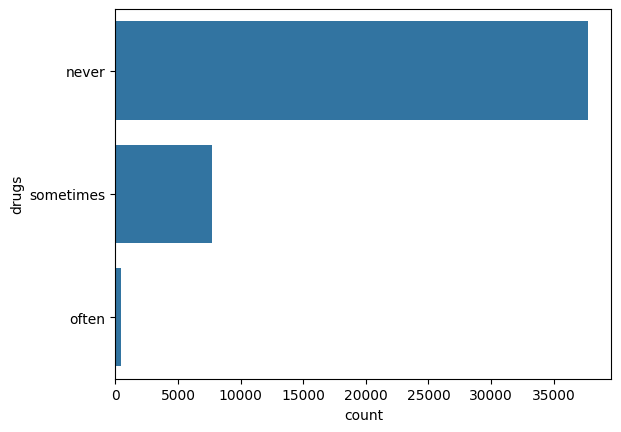

In [98]:
display_count_plot(profiles, "drugs")

### Education

Below you can see the majority of users are graduate from college/university followed by masters programs and those working on college/university. Interestingly space camp related options are fairly a popular options.

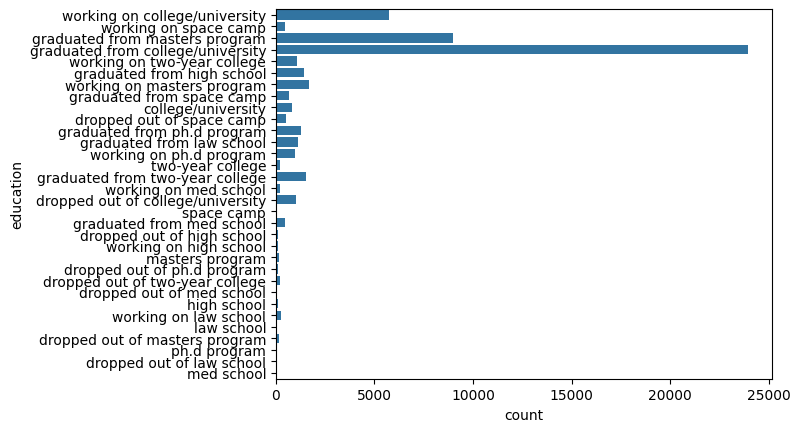

In [99]:
display_count_plot(profiles, "education")

### Jobs

Most of the users don't fit into any of the categories. But there are a fair amount of students, artists, science and business folks

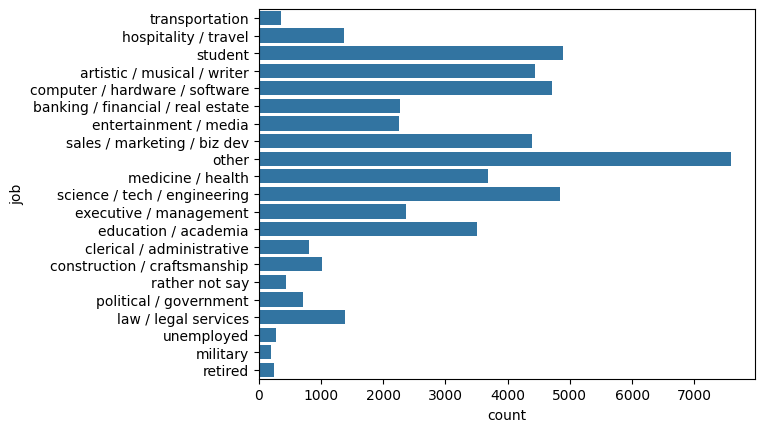

In [100]:
display_count_plot(profiles, "job")

### Offsprings

Most users don't have kids

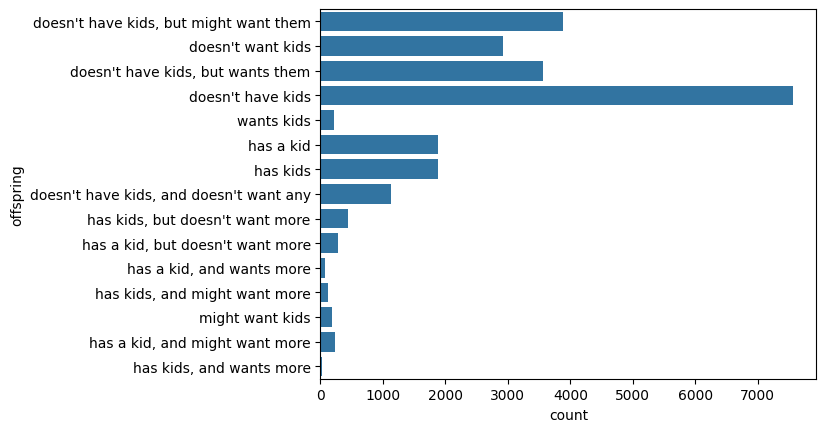

In [101]:
display_count_plot(profiles, "offspring")

### Orientations

Most of the users identify as straight

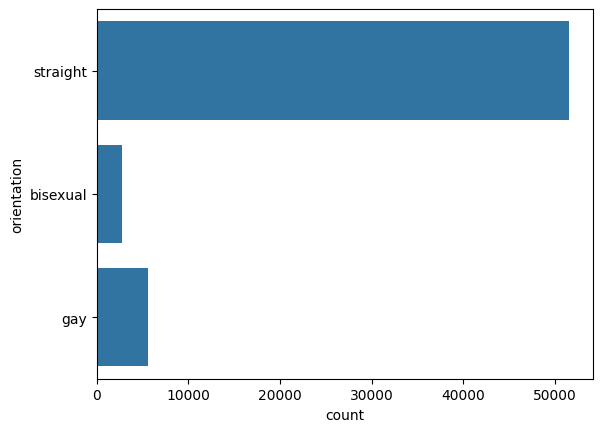

In [102]:
display_count_plot(profiles, "orientation")

Interestingly, the majority of bisexual users are female

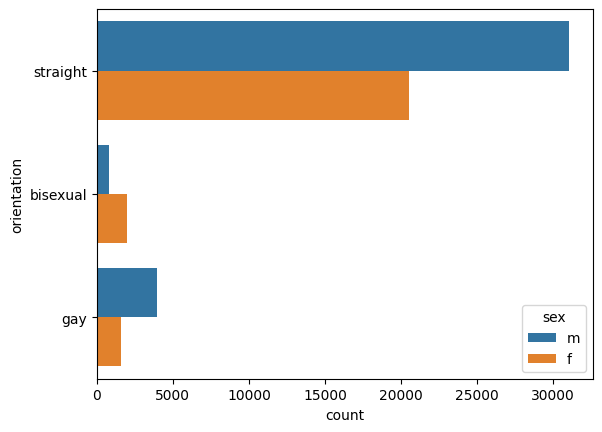

In [103]:
display_count_plot(profiles, "orientation", hue="sex")

### Pets

The chart shows that most users like or have dogs.


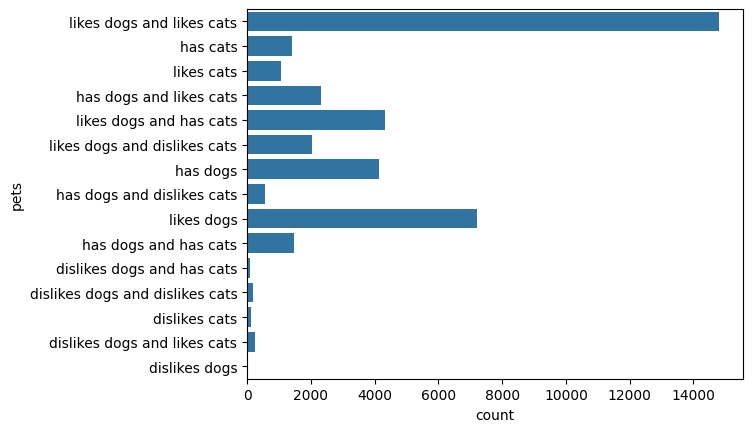

In [104]:
display_count_plot(profiles, "pets")

### Religion 

Religion was similar to sign where there are a lot of qualifiers.

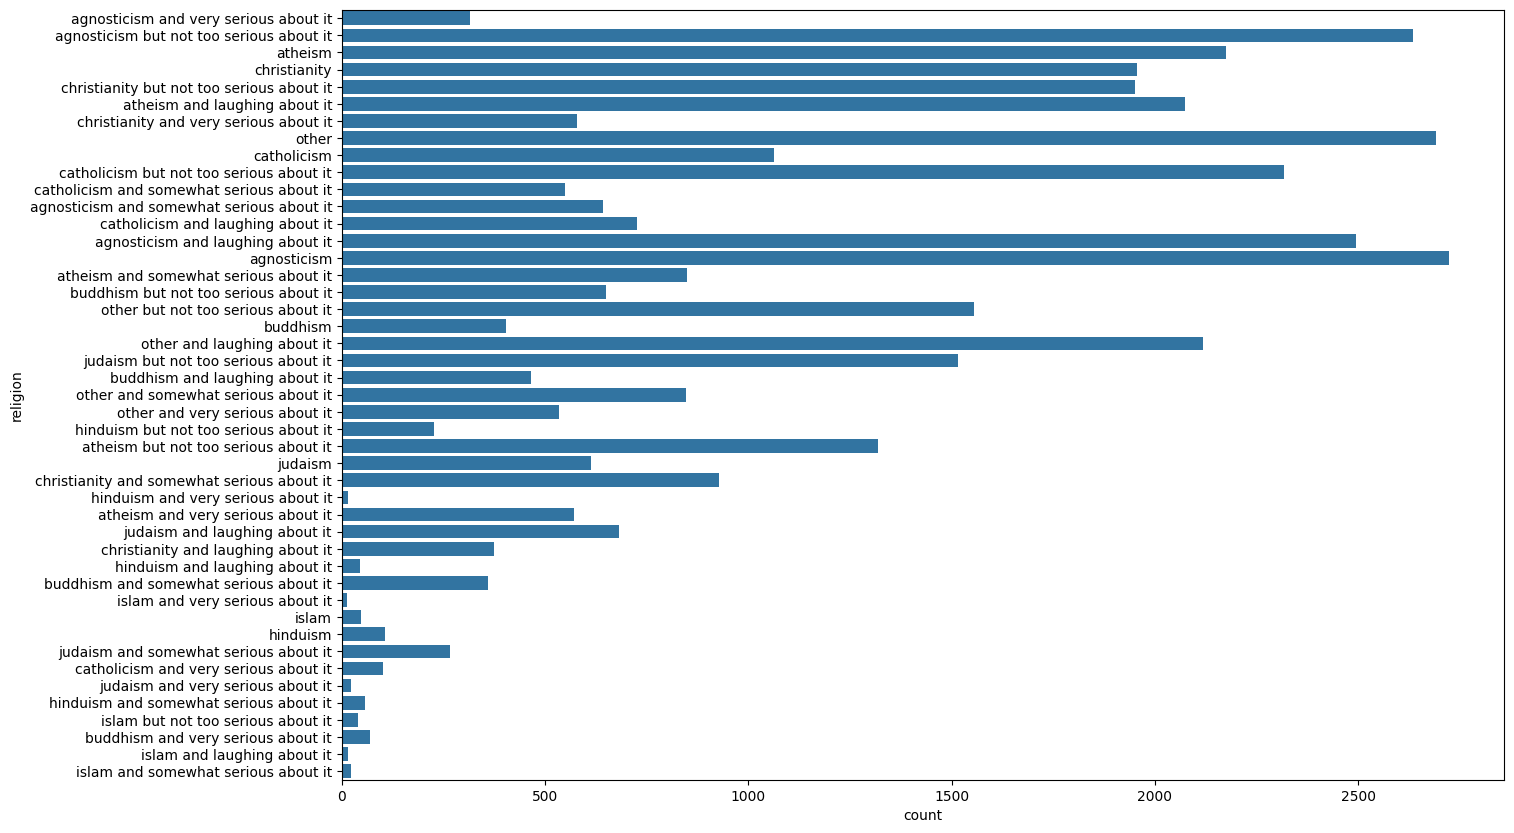

In [105]:
plt.figure(figsize=(15, 10))
display_count_plot(profiles, "religion")

Religion is cleaned to take the first word and distilled to 9 categories. Most of the users identify themselves as agnostic

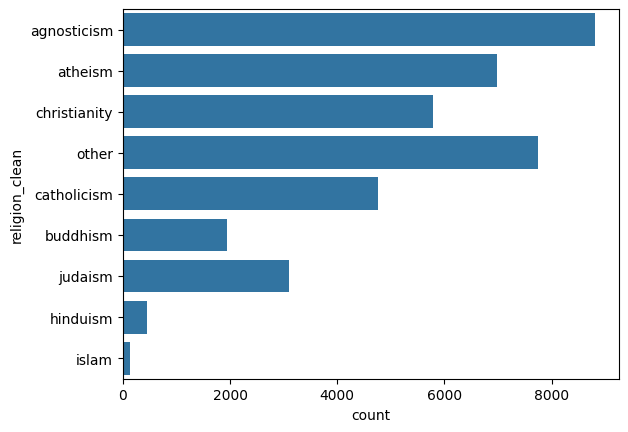

In [106]:
profiles["religion_clean"] = remove_qualifiers_from_column(profiles, "religion")
display_count_plot(profiles, "religion_clean")

### Signs

Here are the astrological signs of the users. There are mainly evenly distributed with Capricorns being the rarest and Leos being the most common.

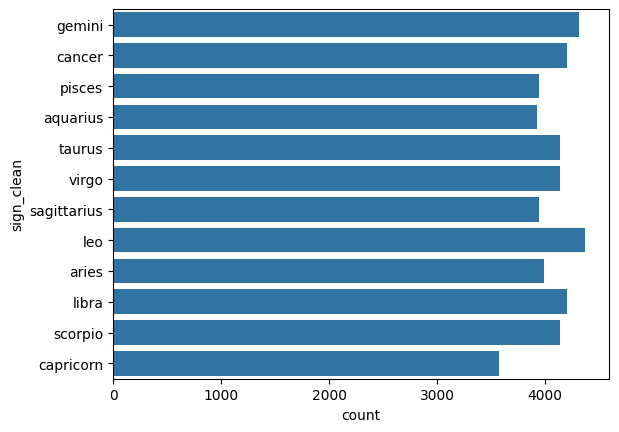

In [107]:
display_count_plot(profiles, "sign_clean")

### Smoking

Same as drugs, most of the users are non-smokers

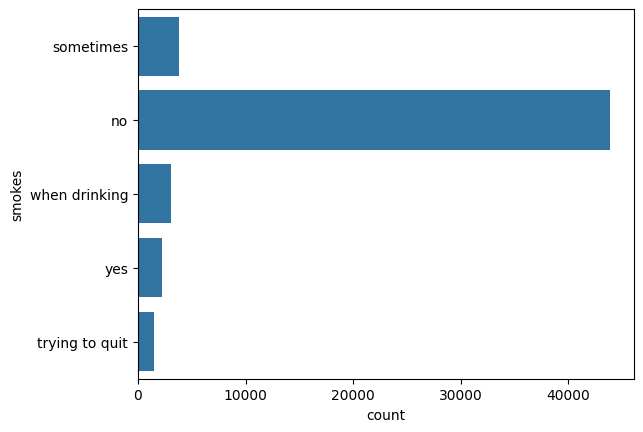

In [108]:
display_count_plot(profiles, "smokes")

### Relationship Status

It probably seems obvious, but most of the users are single and available

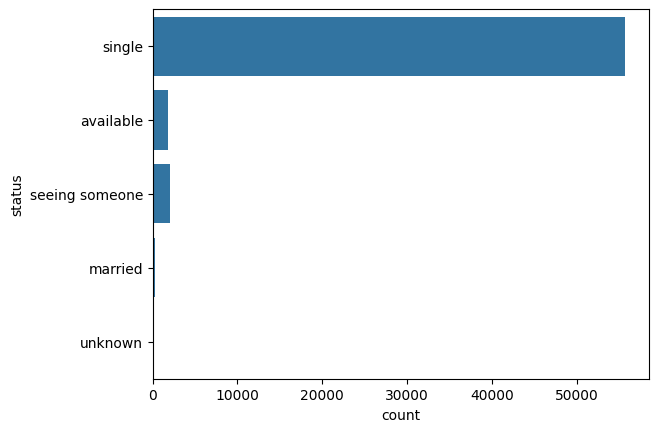

In [109]:
display_count_plot(profiles, "status")

## Data Preparation
### Missing Data
Missing data is not handled very well by machine learning models and has to be imputed or removed. It seems that many of the columns do have missing values.

In [110]:
profiles.isna().sum()

age                   0
status                0
sex                   0
orientation           0
body_type          5296
diet              24395
drinks             2985
drugs             14080
education          6628
ethnicity          5680
height                3
income                0
job                8198
last_online           0
location              0
offspring         35561
pets              19921
religion          20226
sign              11056
smokes             5512
speaks               50
essay0             5488
essay1             7572
essay2             9638
essay3            11476
essay4            10537
essay5            10850
essay6            13771
essay7            12451
essay8            19225
essay9            12603
sign_clean        11056
religion_clean    20226
dtype: int64

### Preprocessing
Preparing the data for modeling is important since it can speed up the process and produce better models. As the adage goes, "garbage in garbage out" so we want to make sure the data we are inputting into our modeling step is good enough to share with others.
The data for the model is going to be a subset of the variables. The variables were selected because they might be a good predictor for astrological signs, where some of the variables that were not selected such as `age` is probably not a good indicator.

Here na values are dropped to create a fully complete data set.

In [111]:
cols = ['body_type', 'diet', 'orientation', 'pets', 'religion_clean',
       'sex', 'job', 'sign_clean']
df = profiles[cols].dropna()
df.shape

(16453, 8)

### Dummy Variables

In the next step all predictor categorical variables are encoded using the so-called One Hot Encoding. One Hot Encoding transforms each of the categories in the categorical variable into a separate feature (column) with a binary value (1 -> True or 0 -> False).

In [112]:
for col in cols[:-1]:
    df = pd.get_dummies(df, columns=[col], prefix=[col], dtype=int)
df.head()

,sign_clean,body_type_a little extra,body_type_athletic,body_type_average,body_type_curvy,body_type_fit,body_type_full figured,body_type_jacked,body_type_overweight,body_type_rather not say,...,job_military,job_other,job_political / government,job_rather not say,job_retired,job_sales / marketing / biz dev,job_science / tech / engineering,job_student,job_transportation,job_unemployed
0,gemini,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,cancer,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,taurus,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,sagittarius,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,cancer,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


### Lable Imbalance
An imbalance in the prediction label needs to be checked. This is important since it's a multi-class problem where two or more outcomes can be had. An imbalance in a response variable is bad since it means that some labels only occur a few times. This is an issue for machine learning algorithms if there are not enough data to train with which will give bad predictions.

In the given dataset, we observe that the counts of all the zodiac signs are more or less equal (i.e., without large deviations). Hence, we do not have to worry about imbalances and trying to address this problem.

In [113]:
from utils.visualizations import column_value_counts

print(column_value_counts(df, "sign_clean"))

sign_clean
leo            1516
gemini         1496
cancer         1457
virgo          1451
taurus         1390
scorpio        1356
libra          1354
pisces         1334
aries          1328
sagittarius    1312
aquarius       1262
capricorn      1197
Name: count, dtype: int64


### Splitting the data
Next the data needs to be split into train and test sets. Here 75% of the data is used to train the model and 25% for final evaluation

In [114]:
col_length = len(df.columns)

X = df.iloc[:, 1: col_length]
y = df.iloc[:, 0: 1]

test_size = 0.25

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=test_size, random_state=0)

y_train = y_train.to_numpy().ravel()
y_test = y_test.to_numpy().ravel()

## Prediction

### Model Building
Now it's time to train a few models and see how they perform. Below we import some models I think are appropriate for the problem we are trying to solve and the data we have.

In [115]:
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#### Evaluation Metrics

In the models, there will be several values that can be evaluated below is a quick diagram:
![](https://miro.medium.com/max/1400/1*UVP_xb4F6J-M-xH3haz5Jw.png)
here is a quick description of the metrics:

- **Accuracy:** is the correct values divided by total values
- **Precision:** is the True Positives divided by the sum of True Positives and False Negatives. So precision is the values of the true positives divided by the actual positive values.
- **Recall:** is the True Positives divided by the sum of True Positives and False Positives. So recall is the values of the true positives divided by the positive guesses.
- **F1-score:** is a blended score of precision and recall which balances both values.
- **Macro Avg:** is the unweighted mean value of precision and recall.
- **Weighted Avg:** is the weighted mean value of precision and recall by the support values for each class.
- **Support:** is the number of observations in class to predict.

### Linear Support Vector Classifier
Linear Support Vector Classifier is a Support Vector Machine Classifier similar to a Support Vector Classifier with `kernel="linear"` hyperparameter.
It's implemented using liblinear instead of libsvm optimization algorithm, so it has more flexibility in terms of choice of penalties and loss functions and should scale better with large datasets

In [116]:
from sklearn.metrics import f1_score, make_scorer
from utils.model_training import train_model, evaluate_model

# Create the classifier
linear_svc = LinearSVC()

# Fit the classifier to training data
linear_svc = train_model(linear_svc, X_train, y_train)

The final accuracy of the model is 8% which is very bad

In [117]:
# Evaluate the model on test data
evaluate_model(linear_svc, X_test, y_test, "accuracy")

LinearSVC()'s accuracy score
0.0839


### K Nearest Neighbors
The next models is the `KNeighborsClassifier`. The default value for `n_neighbors` is 5 which was kept. This number can be tuned later on if needed. This model had a 9% accuracy which is also bad.

In [118]:
knn = KNeighborsClassifier()

knn = train_model(knn, X_train, y_train)

# Evaluate the model on test data
evaluate_model(knn, X_test, y_test, "accuracy")

KNeighborsClassifier()'s accuracy score
0.0861


### Random Forest Classifier
The last model is a Random Forest Classifier. Here `max_depth` is kept to the default value of `None` which means that it will "If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples."

In [119]:
rf = RandomForestClassifier()
rf = train_model(rf, X_train, y_train)

Unfortunately this model also has poor performance

In [120]:
evaluate_model(rf, X_test, y_test, "accuracy")

RandomForestClassifier()'s accuracy score
0.0865


## Hyperparameter Tuning

In this step we'll try to improve our models by tuning some of their hyperparameters

### Linear Support Vector Classifier
Here we are going to tune `C` hyperparameter of our Linear SVC to check whether that will improve its performance. We'll use `RandomizedSearchCV` with 5-fold cross-validation on a predefined list of values

In [121]:
from utils.hp_tuning import tune_model_hyperparameters

param_grid = {
    "C": [0.1, 1, 10, 100, 1000]
}

rand_search = tune_model_hyperparameters(linear_svc, param_grid, "accuracy", 5, X_train, y_train)



c:\Users\ilian\VS Code Projects\course_project\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Looks like the hyperparameter tuning did nothing for our model's accuracy. It's still low

In [122]:
best_svc = rand_search.best_estimator_
evaluate_model(best_svc, X_test, y_test, "accuracy")

LinearSVC(C=1000)'s accuracy score
0.0828


### K Nearest Neighbors

Now we are going to tune our KNN classifier's `n_neighbors` hyperparameter

In [123]:
param_grid = {
    "n_neighbors": [5, 8, 12, 15]
}

rand_search = tune_model_hyperparameters(
    knn, 
    param_grid, 
    "accuracy", 
    cross_val_splits=5, 
    train_set_features=X_train, 
    train_set_labels=y_train
)

c:\Users\ilian\VS Code Projects\course_project\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


The KNN Classifier doesn't perform better either

In [124]:
best_knn = rand_search.best_estimator_
evaluate_model(best_knn, X_test, y_test, "accuracy")

KNeighborsClassifier(n_neighbors=8)'s accuracy score
0.0881


### Random Forest Classifier

Lastly we'll tune some of the hyperparameter of our Random Forest Classifier

In [125]:
param_grid = {
    "n_estimators": [300, 400, 500, 600],
    "max_depth": [None, 2, 4, 6, 8],
}

rand_search = tune_model_hyperparameters(
    rf, 
    param_grid, 
    "accuracy", 
    cross_val_splits=5, 
    train_set_features=X_train, 
    train_set_labels=y_train
)

Unfortunately even after hyperparameter tuning the Random Forest Classifier's performance is still terrible

In [126]:
best_rf = rand_search.best_estimator_
evaluate_model(best_rf, X_test, y_test, "accuracy")

RandomForestClassifier(max_depth=4, n_estimators=600)'s accuracy score
0.0859


## Conclusion

#### General Comments

In this project machine learning was used to predict the astrological signs of OkCupid users. This is an important feature since many people believe in astrology and matches between compatible star signs. If users don't input their signs, an algorithmic solution could have generated a sign to impute missing data when making matches.

Alas, the selected algorithms did no better than basic guessing.

#### Next Steps

Next steps will be to seriously consider whether it is possible to predict user's astrological signs period, or if there is a way to do with more data. Another possibility is to add additional models or tune more of the hyperparameters of the used models to see if any more predictive power could be squeezed out of the algorithms.

# Problem 2: Can we use lifestyle information ('diet', 'smoking', 'drinking', 'drugs usage'), sex and age to predict body type?

In [127]:
# Create a copy of profiles dataframe
profiles_copy = profiles.copy()
profiles_copy.head()

,age,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,...,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9,sign_clean,religion_clean
0,22,single,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",...,making people laugh. ranting about a good salt...,"the way i look. i am a six foot half asian, ha...","books: absurdistan, the republic, of mice and ...",food. water. cell phone. shelter.,duality and humorous things,trying to find someone to hang out with. i am ...,i am new to california and looking for someone...,you want to be swept off your feet! you are ti...,gemini,agnosticism
1,35,single,m,straight,average,mostly other,often,sometimes,working on space camp,white,...,being silly. having ridiculous amonts of fun w...,NaN,i am die hard christopher moore fan. i don't r...,delicious porkness in all of its glories. my b...,NaN,NaN,i am very open and will share just about anyth...,NaN,cancer,agnosticism
2,38,available,m,straight,thin,anything,socially,NaN,graduated from masters program,NaN,...,improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,okay this is where the cultural matrix gets so...,movement conversation creation contemplation t...,NaN,viewing. listening. dancing. talking. drinking...,"when i was five years old, i was known as ""the...","you are bright, open, intense, silly, ironic, ...",pisces,NaN
3,23,single,m,straight,thin,vegetarian,socially,NaN,working on college/university,white,...,playing synthesizers and organizing books acco...,socially awkward but i do my best,"bataille, celine, beckett. . . lynch, jarmusch...",NaN,cats and german philosophy,NaN,NaN,you feel so inclined.,pisces,NaN
4,29,single,m,straight,athletic,NaN,socially,never,graduated from college/university,"asian, black, other",...,creating imagery to look at: http://bagsbrown....,i smile a lot and my inquisitive nature,"music: bands, rappers, musicians at the moment...",NaN,NaN,NaN,NaN,NaN,aquarius,NaN


## Data Preparation

### Missing Data

In [128]:
profiles_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 33 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             59946 non-null  int64  
 1   status          59946 non-null  str    
 2   sex             59946 non-null  str    
 3   orientation     59946 non-null  str    
 4   body_type       54650 non-null  str    
 5   diet            35551 non-null  str    
 6   drinks          56961 non-null  str    
 7   drugs           45866 non-null  str    
 8   education       53318 non-null  str    
 9   ethnicity       54266 non-null  str    
 10  height          59943 non-null  float64
 11  income          59946 non-null  int64  
 12  job             51748 non-null  str    
 13  last_online     59946 non-null  str    
 14  location        59946 non-null  str    
 15  offspring       24385 non-null  str    
 16  pets            40025 non-null  str    
 17  religion        39720 non-null  str    
 1

Some of our predictor features have missing values. Here we inpute them by using a  meaningful value

In [129]:
profiles_copy["diet"] = profiles_copy["diet"].fillna("other")
profiles_copy["body_type"] = profiles_copy["body_type"].fillna("other")
profiles_copy["drinks"] = profiles_copy["drinks"].fillna("rather not say")
profiles_copy["drugs"] = profiles_copy["drugs"].fillna("never")
profiles_copy["smokes"] = profiles_copy["smokes"].fillna("rather not say")

### Preprocessing

In [130]:
print(column_value_counts(df=profiles_copy, column="diet"))

diet
other                  24726
mostly anything        16585
anything                6183
strictly anything       5113
mostly vegetarian       3444
mostly other            1007
strictly vegetarian      875
vegetarian               667
strictly other           452
mostly vegan             338
strictly vegan           228
vegan                    136
mostly kosher             86
mostly halal              48
strictly halal            18
strictly kosher           18
halal                     11
kosher                    11
Name: count, dtype: int64


Here we clean the `diet` column and reduce the number categories in it. This is done because some of the categories have duplicate information and have very little observations connected to them 

In [131]:
profiles_copy["diet_clean"] = profiles_copy["diet"].str.replace("mostly", "").str.replace("strictly", "").str.strip()
print(column_value_counts(profiles_copy, "diet_clean"))
print(column_value_counts(profiles_copy, "smokes"))
print(column_value_counts(profiles_copy, "body_type"))
print(column_value_counts(profiles_copy, "drinks"))

diet_clean
anything      27881
other         26185
vegetarian     4986
vegan           702
kosher          115
halal            77
Name: count, dtype: int64
smokes
no                43896
rather not say     5512
sometimes          3787
when drinking      3040
yes                2231
trying to quit     1480
Name: count, dtype: int64
body_type
average           14652
fit               12711
athletic          11819
other              5296
thin               4711
curvy              3924
a little extra     2629
skinny             1777
full figured       1009
overweight          444
jacked              421
used up             355
rather not say      198
Name: count, dtype: int64
drinks
socially          41780
rarely             5957
often              5164
not at all         3267
rather not say     2985
very often          471
desperately         322
Name: count, dtype: int64


### One-Hot Encoding

Here we encode `diet_clean`, `smokes`, `drinks` and `drugs` columns using One-Hot Encoding

In [132]:
ohe_df = pd.get_dummies(profiles_copy[["diet_clean", "smokes", "drinks", "drugs"]], dtype=int)
ohe_df["age"] = profiles_copy["age"]
ohe_df.head()

,diet_clean_anything,diet_clean_halal,diet_clean_kosher,diet_clean_other,diet_clean_vegan,diet_clean_vegetarian,smokes_no,smokes_rather not say,smokes_sometimes,smokes_trying to quit,...,drinks_not at all,drinks_often,drinks_rarely,drinks_rather not say,drinks_socially,drinks_very often,drugs_never,drugs_often,drugs_sometimes,age
0,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,1,0,0,22
1,0,0,0,1,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,1,35
2,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,1,0,0,38
3,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,1,0,1,0,0,23
4,0,0,0,1,0,0,1,0,0,0,...,0,0,0,0,1,0,1,0,0,29


### Label Encoding

Now we encode the target column `body_type` and the `sex` column using Label Encoding

In [133]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

encoder = LabelEncoder()
body_type_encoded = encoder.fit_transform(profiles_copy["body_type"])

sex_encoded = encoder.fit_transform(profiles_copy["sex"])
ohe_df["sex"] = sex_encoded

### Splitting the Data

Here the `stratify` parameter is added to ensure that we get an equal number of samples per class in both of training set and test set since we have underrepresented classes in our target feature.

In [134]:
X = ohe_df
y = body_type_encoded

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=0, 
    stratify=y
)

# Scale data to avoid biasing scale sensitive models
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Prediction

### Model Building

Now it's time to train our models and see how they perform on body type prediction. Here the models are evaluated using f1 score instead of accuracy to account for the label imbalance in the target variable

### Linear Support Vector Classifier

In [135]:
linear_svc = LinearSVC(class_weight="balanced")
linear_svc = train_model(linear_svc, X_train_scaled, y_train)

Here it seems that the model is not performing well. The f1 socre is pretty low across all classes and that indicates that there is an underfitting problem and the model is too simple to capture the underlying patterns in the data 

In [136]:
# Evaluate the model on train data
evaluate_model(linear_svc, X_train_scaled, y_train, "f1")

LinearSVC(class_weight='balanced')'s f1 score
0.1422


The test set is score is also poor since given the underfitting problem the model hasn't learned anything so it can't also generalize to new data

In [137]:
# Evaluate the model on test data
evaluate_model(linear_svc, X_test_scaled, y_test, "f1")

LinearSVC(class_weight='balanced')'s f1 score
0.1390


### K-Nearest Knieghbors

In [138]:
knn = KNeighborsClassifier()
knn = train_model(knn, X_train_scaled, y_train)

The KNN model also seems to underfit

In [139]:
evaluate_model(knn, X_train_scaled, y_train, "f1")
evaluate_model(knn, X_test_scaled, y_test, "f1")

KNeighborsClassifier()'s f1 score
0.2808
KNeighborsClassifier()'s f1 score
0.2049


### Random Forest Classifier

In [140]:
rf = RandomForestClassifier()
rf = train_model(rf, X_train, y_train)

The Random forest model also performs badly. Although it has slightly higher f1 score on the train set it still doesn't generalize well on new data

In [141]:
evaluate_model(rf, X_train, y_train, "f1")

RandomForestClassifier()'s f1 score
0.3725


In [142]:
evaluate_model(rf, X_test, y_test, "f1")

RandomForestClassifier()'s f1 score
0.2220
